In [1]:
from google.cloud import bigquery
import pandas as pd
import os
from dotenv import load_dotenv

load_dotenv()
PROJECT_ID = os.getenv('GCP_PROJECT_ID')
DATASET_ID = os.getenv('BIGQUERY_DATASET_ID')

In [2]:
!pip install google-cloud-bigquery-storage pyarrow fastparquet



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
client = bigquery.Client()

query = f"""
SELECT
    pitcher,
    player_name,
    pitch_type,
    pitch_name,
    
    -- features
    release_speed,
    release_spin_rate,
    spin_axis,
    pfx_x,
    pfx_z,
    release_extension,
    release_pos_x,
    release_pos_z,
    plate_x,
    plate_z,
    api_break_z_with_gravity,
    api_break_x_arm,
    arm_angle,
    vx0, vy0, vz0,
    ax, ay, az,

    -- target variable
    woba_value,
    delta_pitcher_run_exp,

    -- metadata
    game_year,
    p_throws,
    stand
FROM `{PROJECT_ID}.{DATASET_ID}.statcast_master`
WHERE game_year = 2025
    AND pitch_type IS NOT NULL
    AND release_speed IS NOT NULL
    AND woba_value IS NOT NULL
"""

df = client.query(query).to_dataframe()
print(f"Records {len(df):,}")
print(f"Pitchers: {df['pitcher'].nunique()}")
print(f"Pitch types: {df['pitch_type'].unique()}")

Records 718,519
Pitchers: 873
Pitch types: ['SV' 'PO' 'EP' 'FA' 'FO' 'CS' 'KN' 'SC' 'CH' 'CU' 'FC' 'FF' 'FS' 'KC'
 'SI' 'SL' 'ST']


In [4]:
# ============================================================
# Pitching+ Features（球質 + 投球位置 = 総合指標）
# plate_x, plate_z を含む → 制球も評価に入る
# ============================================================
FEATURES = [
    'release_speed', 'release_spin_rate', 'spin_axis',
    'pfx_x', 'pfx_z', 'release_extension',
    'release_pos_x', 'release_pos_z',
    'plate_x', 'plate_z',
    'api_break_z_with_gravity', 'api_break_x_arm',
    'arm_angle',
]

print("=== Pitching+ Features (球質 + 制球) ===")
print(df[FEATURES].isnull().sum())
print(df[FEATURES].describe())

=== Pitching+ Features (球質 + 制球) ===
release_speed               0
release_spin_rate           0
spin_axis                   0
pfx_x                       0
pfx_z                       0
release_extension           0
release_pos_x               0
release_pos_z               0
plate_x                     0
plate_z                     0
api_break_z_with_gravity    0
api_break_x_arm             0
arm_angle                   0
dtype: int64
       release_speed  release_spin_rate   spin_axis          pfx_x  \
count  718519.000000           718519.0    718519.0  718519.000000   
mean       89.303046        2269.330172  177.278914      -0.128342   
std         6.733189         387.745524   73.803372       0.899823   
min         0.000000                0.0         0.0      -2.450000   
25%        85.100000             2134.0       130.0      -0.900000   
50%        90.200000             2314.0       202.0      -0.200000   
75%        94.300000             2484.0       225.0       0.580000   


In [5]:
!pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [7]:
# Drop null value (.copy() で明示的にコピーを作成し SettingWithCopyWarning を回避)
df_clean = df.dropna(subset=FEATURES + ["pitch_type", "delta_pitcher_run_exp"]).copy()
print(f"df_clean: {len(df_clean):,} rows (dropped {len(df) - len(df_clean):,} nulls)")

df_clean: 718,519 rows (dropped 0 nulls)


In [8]:
# pitch_type を One-Hot Encoding して追加
df_encoded = pd.get_dummies(df_clean[FEATURES + ["pitch_type"]], columns=["pitch_type"])
print(f"df_encoded shape: {df_encoded.shape}")
print(f"columns: {list(df_encoded.columns)}")

df_encoded shape: (718519, 30)
columns: ['release_speed', 'release_spin_rate', 'spin_axis', 'pfx_x', 'pfx_z', 'release_extension', 'release_pos_x', 'release_pos_z', 'plate_x', 'plate_z', 'api_break_z_with_gravity', 'api_break_x_arm', 'arm_angle', 'pitch_type_CH', 'pitch_type_CS', 'pitch_type_CU', 'pitch_type_EP', 'pitch_type_FA', 'pitch_type_FC', 'pitch_type_FF', 'pitch_type_FO', 'pitch_type_FS', 'pitch_type_KC', 'pitch_type_KN', 'pitch_type_PO', 'pitch_type_SC', 'pitch_type_SI', 'pitch_type_SL', 'pitch_type_ST', 'pitch_type_SV']


In [9]:
# XGBoost 学習
X = df_encoded
y = df_clean["delta_pitcher_run_exp"].values  # .values で numpy array にして index 不一致を回避

print(f"X shape: {X.shape}, y shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)

X shape: (718519, 30), y shape: (718519,)
[0]	validation_0-rmse:0.22610
[50]	validation_0-rmse:0.22419
[100]	validation_0-rmse:0.22403
[150]	validation_0-rmse:0.22399
[200]	validation_0-rmse:0.22399
[234]	validation_0-rmse:0.22399


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,None


In [10]:
y_pred = model.predict(X_test)
print(f"=== Pitch-Level Metrics (1球単位 → 低R²は想定内) ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print()
print("※ 1球単位のR²が低いのは正常。Stuff+の価値は投手×球種に集約した後に出る。")

=== Pitch-Level Metrics (1球単位 → 低R²は想定内) ===
RMSE: 0.2240
R²:   0.0196

※ 1球単位のR²が低いのは正常。Stuff+の価値は投手×球種に集約した後に出る。


In [11]:
# 全データに対する予測値
df_clean["predicted_run_exp"] = model.predict(df_encoded)
print(f"predicted_run_exp: mean={df_clean['predicted_run_exp'].mean():.6f}, std={df_clean['predicted_run_exp'].std():.6f}")

predicted_run_exp: mean=-0.000268, std=0.030135


In [12]:
# ============================================================
# Pitching+ スコア算出（投手×球種レベルに集約してから正規化）
# ============================================================
# delta_pitcher_run_exp: 負の値 = 投手有利
# predicted_run_exp が大きく負 = "stuff が良い"
#
# 正規化: z-score ベース（100 = リーグ平均, 15pt = 1σ）
# pitching_plus = 100 + (league_mean - pitcher_mean) / league_std * 15
# ============================================================

# Step 1: 投手 × 球種ごとに集約
pitching_ranking = (
    df_clean
    .groupby(["pitcher", "player_name", "pitch_name"])
    .agg(
        mean_pred_run_exp=("predicted_run_exp", "mean"),
        actual_run_exp=("delta_pitcher_run_exp", "mean"),
        pitch_count=("predicted_run_exp", "count"),
        avg_velo=("release_speed", "mean"),
        avg_spin=("release_spin_rate", "mean"),
    )
    .reset_index()
    .query("pitch_count >= 100")
)

# Step 2: z-score 正規化 → Pitching+ スケール
mu_p = pitching_ranking["mean_pred_run_exp"].mean()
sigma_p = pitching_ranking["mean_pred_run_exp"].std()

pitching_ranking["pitching_plus"] = 100 + (mu_p - pitching_ranking["mean_pred_run_exp"]) / sigma_p * 15

print(f"集約後レコード数: {len(pitching_ranking)}")
print(f"league_mean: {mu_p:.6f}, league_std: {sigma_p:.6f}")
print(f"Pitching+ 分布: mean={pitching_ranking['pitching_plus'].mean():.1f}, "
      f"std={pitching_ranking['pitching_plus'].std():.1f}, "
      f"min={pitching_ranking['pitching_plus'].min():.1f}, "
      f"max={pitching_ranking['pitching_plus'].max():.1f}")

集約後レコード数: 1949
league_mean: -0.000720, league_std: 0.005669
Pitching+ 分布: mean=100.0, std=15.0, min=49.6, max=273.4


In [13]:
# Pitching+ ランキング TOP 20
ranking_display_p = (
    pitching_ranking
    .sort_values("pitching_plus", ascending=False)
    [["player_name", "pitch_name", "pitching_plus", "pitch_count", "avg_velo", "avg_spin", "actual_run_exp"]]
    .round(1)
)

print("=== Pitching+ Ranking TOP 20 (球質+制球) ===")
print(ranking_display_p.head(20).to_string(index=False))
print()
print("=== Pitching+ Ranking BOTTOM 10 ===")
print(ranking_display_p.tail(10).to_string(index=False))

=== Pitching+ Ranking TOP 20 (球質+制球) ===
          player_name      pitch_name  pitching_plus  pitch_count  avg_velo  avg_spin  actual_run_exp
       Sanoja, Javier           Other     273.399994          168      62.6    1579.3            -0.1
          Pérez, Eury        Changeup     170.100006          131      89.7    1741.9            -0.0
         Kelly, Kevin         Sweeper     169.600006          116      78.7    2546.2            -0.1
     Alexander, Jason 4-Seam Fastball     158.300003          126      91.9    2269.7            -0.0
    Rutledge, Jackson    Split-Finger     146.800003          126      85.2    1369.7            -0.0
          Eflin, Zach 4-Seam Fastball     142.600006          144      92.0    2179.1            -0.0
     Ribalta, Orlando        Changeup     142.100006          105      85.5    1934.1            -0.0
       Gaddis, Hunter        Changeup     141.800003          149      78.8    2036.8            -0.0
      Alvarado, Elvis          Slider    

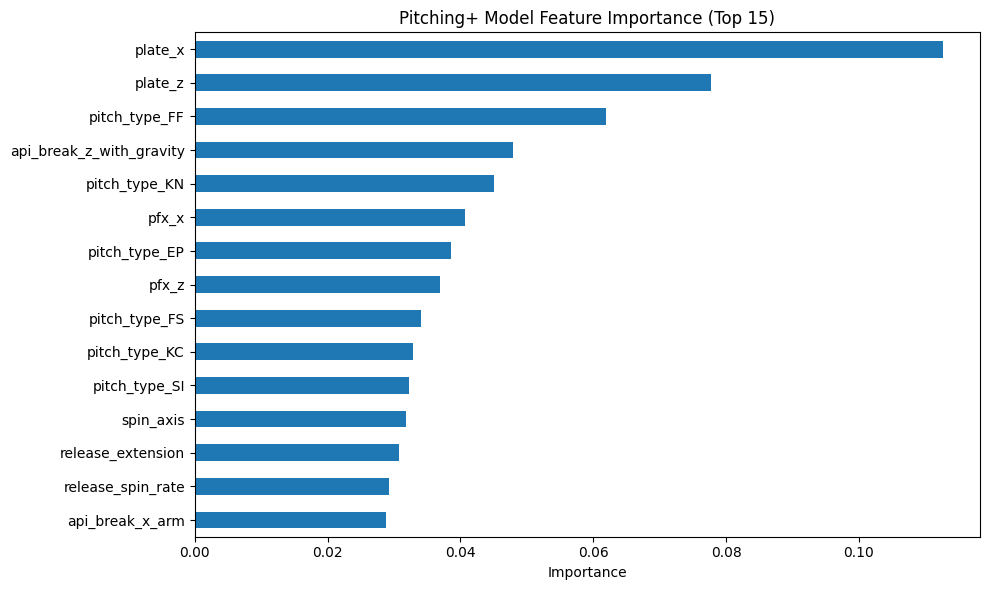

In [14]:
# ============================================================
# Pitching+ Feature Importance
# ============================================================
import matplotlib.pyplot as plt

importance_p = pd.Series(
    model.feature_importances_, index=df_encoded.columns
).sort_values(ascending=True)

importance_p.tail(15).plot(kind="barh", figsize=(10, 6))
plt.title("Pitching+ Model Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

=== Pitching+ 集約レベル（投手×球種）でのバリデーション ===
Pearson相関:  0.3875 (p=7.58e-71)
Spearman相関: 0.3804 (p=4.00e-68)



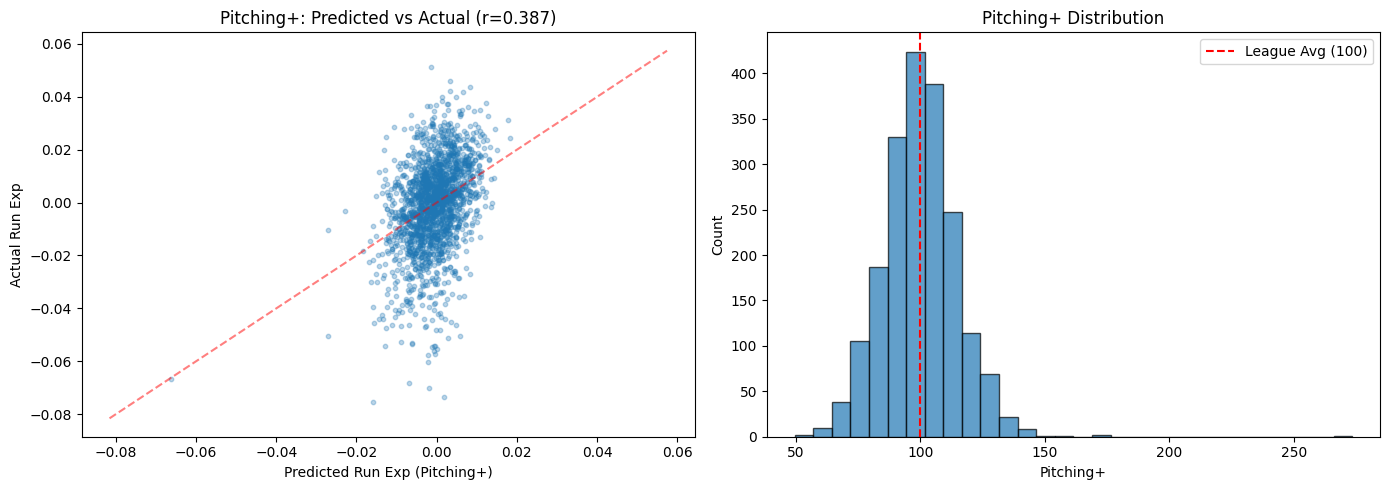

In [15]:
# ============================================================
# Pitching+ バリデーション: 集約レベルでの予測 vs 実際の相関
# ============================================================
from scipy.stats import pearsonr, spearmanr

corr_pearson_p, p_pearson_p = pearsonr(
    pitching_ranking["mean_pred_run_exp"],
    pitching_ranking["actual_run_exp"]
)
corr_spearman_p, p_spearman_p = spearmanr(
    pitching_ranking["mean_pred_run_exp"],
    pitching_ranking["actual_run_exp"]
)

print("=== Pitching+ 集約レベル（投手×球種）でのバリデーション ===")
print(f"Pearson相関:  {corr_pearson_p:.4f} (p={p_pearson_p:.2e})")
print(f"Spearman相関: {corr_spearman_p:.4f} (p={p_spearman_p:.2e})")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    pitching_ranking["mean_pred_run_exp"],
    pitching_ranking["actual_run_exp"],
    alpha=0.3, s=10
)
axes[0].set_xlabel("Predicted Run Exp (Pitching+)")
axes[0].set_ylabel("Actual Run Exp")
axes[0].set_title(f"Pitching+: Predicted vs Actual (r={corr_pearson_p:.3f})")
lims = [
    min(axes[0].get_xlim()[0], axes[0].get_ylim()[0]),
    max(axes[0].get_xlim()[1], axes[0].get_ylim()[1])
]
axes[0].plot(lims, lims, 'r--', alpha=0.5)

axes[1].hist(pitching_ranking["pitching_plus"], bins=30, edgecolor="black", alpha=0.7)
axes[1].axvline(x=100, color="red", linestyle="--", label="League Avg (100)")
axes[1].set_xlabel("Pitching+")
axes[1].set_ylabel("Count")
axes[1].set_title("Pitching+ Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Pure Stuff+ Model（plate_x / plate_z 除外）

上記 Pitching+ は `plate_x`, `plate_z`（投球位置）を含む **球質＋制球の総合指標**。

ここでは投球位置を除外し、**純粋な球質（Stuff）のみ** を評価するモデルを構築する。

| 指標 | 特徴量 | 測定対象 |
|------|--------|---------|
| **Stuff+** | 速度, 回転, 変化量, リリース, arm angle | 球質のみ |
| **Pitching+** | 上記 + plate_x/plate_z | 球質＋制球 |

Hunter Greene の 4-Seam (99.5mph) は Pitching+ では低評価だが、Stuff+ では適正に評価されるはず。

In [16]:
# ============================================================
# Pure Stuff+ Features（plate_x, plate_z を除外）
# ============================================================
STUFF_FEATURES = [
    'release_speed', 'release_spin_rate', 'spin_axis',
    'pfx_x', 'pfx_z', 'release_extension',
    'release_pos_x', 'release_pos_z',
    'api_break_z_with_gravity', 'api_break_x_arm',
    'arm_angle',
]

# データ準備
df_stuff = df.dropna(subset=STUFF_FEATURES + ["pitch_type", "delta_pitcher_run_exp"]).copy()
df_stuff_encoded = pd.get_dummies(df_stuff[STUFF_FEATURES + ["pitch_type"]], columns=["pitch_type"])

X_stuff = df_stuff_encoded
y_stuff = df_stuff["delta_pitcher_run_exp"].values

print(f"=== Pure Stuff+ Features (plate_x/plate_z 除外) ===")
print(f"Features: {STUFF_FEATURES}")
print(f"X_stuff shape: {X_stuff.shape}, y_stuff shape: {y_stuff.shape}")

# Train / Test split
X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(
    X_stuff, y_stuff, test_size=0.2, random_state=42
)

# XGBoost 学習
stuff_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
)
stuff_model.fit(X_s_train, y_s_train, eval_set=[(X_s_test, y_s_test)], verbose=50)

# Pitch-level metrics
y_s_pred = stuff_model.predict(X_s_test)
print(f"\n=== Pure Stuff+ Pitch-Level Metrics ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_s_test, y_s_pred)):.4f}")
print(f"R²:   {r2_score(y_s_test, y_s_pred):.4f}")

=== Pure Stuff+ Features (plate_x/plate_z 除外) ===
Features: ['release_speed', 'release_spin_rate', 'spin_axis', 'pfx_x', 'pfx_z', 'release_extension', 'release_pos_x', 'release_pos_z', 'api_break_z_with_gravity', 'api_break_x_arm', 'arm_angle']
X_stuff shape: (718519, 28), y_stuff shape: (718519,)
[0]	validation_0-rmse:0.22620
[50]	validation_0-rmse:0.22617
[90]	validation_0-rmse:0.22617

=== Pure Stuff+ Pitch-Level Metrics ===
RMSE: 0.2262
R²:   0.0004


In [17]:
# ============================================================
# Stuff+ スコア算出
# ============================================================

# 全データに対する予測
df_stuff["predicted_run_exp_stuff"] = stuff_model.predict(df_stuff_encoded)

# 投手 × 球種ごとに集約
stuff_ranking = (
    df_stuff
    .groupby(["pitcher", "player_name", "pitch_name"])
    .agg(
        mean_pred_run_exp=("predicted_run_exp_stuff", "mean"),
        actual_run_exp=("delta_pitcher_run_exp", "mean"),
        pitch_count=("predicted_run_exp_stuff", "count"),
        avg_velo=("release_speed", "mean"),
        avg_spin=("release_spin_rate", "mean"),
    )
    .reset_index()
    .query("pitch_count >= 100")
)

# z-score 正規化
mu_s = stuff_ranking["mean_pred_run_exp"].mean()
sigma_s = stuff_ranking["mean_pred_run_exp"].std()
stuff_ranking["stuff_plus"] = 100 + (mu_s - stuff_ranking["mean_pred_run_exp"]) / sigma_s * 15

print(f"集約後レコード数: {len(stuff_ranking)}")
print(f"league_mean: {mu_s:.6f}, league_std: {sigma_s:.6f}")
print(f"Stuff+ 分布: mean={stuff_ranking['stuff_plus'].mean():.1f}, "
      f"std={stuff_ranking['stuff_plus'].std():.1f}, "
      f"min={stuff_ranking['stuff_plus'].min():.1f}, "
      f"max={stuff_ranking['stuff_plus'].max():.1f}")

集約後レコード数: 1949
league_mean: -0.000494, league_std: 0.003116
Stuff+ 分布: mean=100.0, std=15.0, min=27.2, max=348.3


In [18]:
# Stuff+ ランキング TOP 20 / BOTTOM 10
ranking_display_s = (
    stuff_ranking
    .sort_values("stuff_plus", ascending=False)
    [["player_name", "pitch_name", "stuff_plus", "pitch_count", "avg_velo", "avg_spin", "actual_run_exp"]]
    .round(1)
)

print("=== Pure Stuff+ Ranking TOP 20 (球質のみ) ===")
print(ranking_display_s.head(20).to_string(index=False))
print()
print("=== Pure Stuff+ Ranking BOTTOM 10 ===")
print(ranking_display_s.tail(10).to_string(index=False))

=== Pure Stuff+ Ranking TOP 20 (球質のみ) ===
        player_name      pitch_name  stuff_plus  pitch_count  avg_velo  avg_spin  actual_run_exp
     Sanoja, Javier           Other  348.299988          168      62.6    1579.3            -0.1
         Lee, Chase         Sweeper  143.500000          209      79.9    2832.1            -0.0
    Hendricks, Kyle       Curveball  142.399994          212      72.2    2822.6            -0.0
       Lopez, Jacob        Changeup  141.000000          223      82.7    2130.4            -0.0
    Hendricks, Kyle 4-Seam Fastball  139.800003          390      86.5    2048.5             0.0
          Moll, Sam         Sweeper  137.899994          148      81.1    2913.5            -0.0
      Herget, Jimmy       Curveball  136.300003          398      77.0    2986.5            -0.0
       Zerpa, Angel 4-Seam Fastball  134.699997          218      96.2    2000.1            -0.0
    Eisert, Brandon        Changeup  134.100006          356      81.7    1300.1     

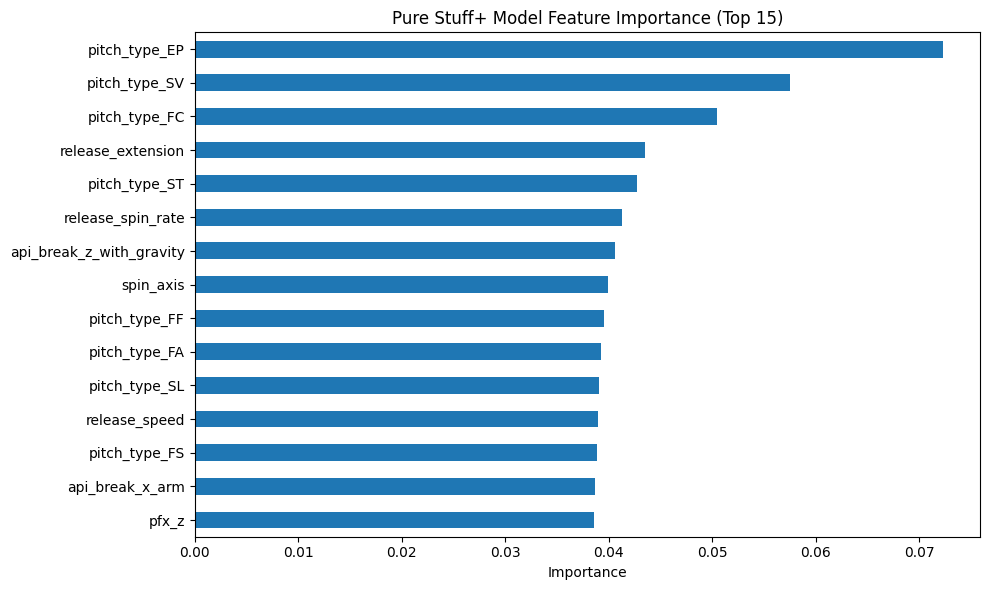

In [19]:
# ============================================================
# Stuff+ Feature Importance
# ============================================================
importance_s = pd.Series(
    stuff_model.feature_importances_, index=df_stuff_encoded.columns
).sort_values(ascending=True)

importance_s.tail(15).plot(kind="barh", figsize=(10, 6))
plt.title("Pure Stuff+ Model Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

=== Pure Stuff+ 集約レベルバリデーション ===
Pearson相関:  0.2871 (p=2.68e-38)
Spearman相関: 0.2752 (p=3.21e-35)



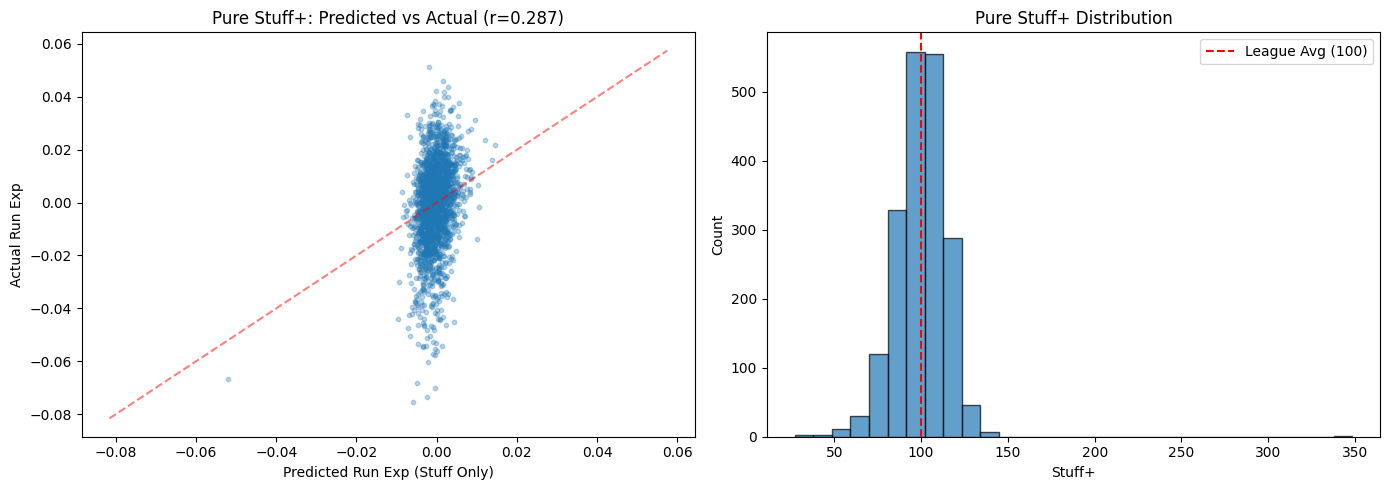

In [20]:
# ============================================================
# Stuff+ バリデーション
# ============================================================
corr_pearson_s, p_pearson_s = pearsonr(
    stuff_ranking["mean_pred_run_exp"],
    stuff_ranking["actual_run_exp"]
)
corr_spearman_s, p_spearman_s = spearmanr(
    stuff_ranking["mean_pred_run_exp"],
    stuff_ranking["actual_run_exp"]
)

print("=== Pure Stuff+ 集約レベルバリデーション ===")
print(f"Pearson相関:  {corr_pearson_s:.4f} (p={p_pearson_s:.2e})")
print(f"Spearman相関: {corr_spearman_s:.4f} (p={p_spearman_s:.2e})")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    stuff_ranking["mean_pred_run_exp"],
    stuff_ranking["actual_run_exp"],
    alpha=0.3, s=10
)
axes[0].set_xlabel("Predicted Run Exp (Stuff Only)")
axes[0].set_ylabel("Actual Run Exp")
axes[0].set_title(f"Pure Stuff+: Predicted vs Actual (r={corr_pearson_s:.3f})")
lims = [
    min(axes[0].get_xlim()[0], axes[0].get_ylim()[0]),
    max(axes[0].get_xlim()[1], axes[0].get_ylim()[1])
]
axes[0].plot(lims, lims, 'r--', alpha=0.5)

axes[1].hist(stuff_ranking["stuff_plus"], bins=30, edgecolor="black", alpha=0.7)
axes[1].axvline(x=100, color="red", linestyle="--", label="League Avg (100)")
axes[1].set_xlabel("Stuff+")
axes[1].set_ylabel("Count")
axes[1].set_title("Pure Stuff+ Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Stuff+ vs Pitching+ 比較

同一投手×球種で Stuff+（球質のみ）と Pitching+（球質＋制球）がどう異なるかを比較する。
特に Greene のように「球質は elite だが制球パターンが独特」な投手で差が出るはず。

In [21]:
# ============================================================
# Stuff+ vs Pitching+ 比較テーブル
# ============================================================

# 両指標をマージ
comparison = stuff_ranking[["pitcher", "player_name", "pitch_name", "stuff_plus", "avg_velo", "avg_spin", "pitch_count"]].merge(
    pitching_ranking[["pitcher", "pitch_name", "pitching_plus"]],
    on=["pitcher", "pitch_name"],
    how="inner"
)

# 差分: Stuff+ が高いのに Pitching+ が低い = 球質は良いが制球パターンで損
comparison["gap"] = comparison["stuff_plus"] - comparison["pitching_plus"]

print("=== Stuff+ >> Pitching+ (球質elite、制球パターンで評価を落とされた投手) ===")
top_gap = comparison.sort_values("gap", ascending=False).head(15)
print(top_gap[["player_name", "pitch_name", "stuff_plus", "pitching_plus", "gap", "avg_velo", "avg_spin"]].round(1).to_string(index=False))

print()
print("=== Pitching+ >> Stuff+ (球質は平凡だが制球で稼いでいる投手) ===")
bot_gap = comparison.sort_values("gap", ascending=True).head(15)
print(bot_gap[["player_name", "pitch_name", "stuff_plus", "pitching_plus", "gap", "avg_velo", "avg_spin"]].round(1).to_string(index=False))

# Greene をハイライト
print()
print("=== Hunter Greene ===")
greene = comparison[comparison["player_name"].str.contains("Greene, Hunter", na=False)]
if greene.empty:
    greene = comparison[comparison["player_name"].str.contains("Greene", na=False)]
print(greene[["player_name", "pitch_name", "stuff_plus", "pitching_plus", "gap", "avg_velo", "avg_spin", "pitch_count"]].round(1).to_string(index=False))

=== Stuff+ >> Pitching+ (球質elite、制球パターンで評価を落とされた投手) ===
        player_name      pitch_name  stuff_plus  pitching_plus       gap  avg_velo  avg_spin
     Sanoja, Javier           Other  348.299988     273.399994 74.900002      62.6    1579.3
      Banks, Tanner 4-Seam Fastball  133.399994      96.199997 37.099998      92.7    2177.4
      Civale, Aaron       Curveball  122.500000      87.699997 34.799999      77.8    3140.3
      Taylor, Grant       Curveball  100.199997      67.599998 32.599998      85.2    2485.8
     Finnegan, Kyle    Split-Finger  106.900002      76.300003 30.600000      87.4    1020.2
  McGreevy, Michael          Sinker  114.699997      85.199997 29.400000      91.8    2200.8
    McFarland, T.J.         Sweeper  103.800003      76.000000 27.799999      78.1    2400.6
       Mahle, Tyler    Split-Finger  110.099998      83.000000 27.100000      84.1    1733.3
Yamamoto, Yoshinobu       Curveball  113.099998      86.800003 26.299999      76.9    2766.6
       Lopez, 

C:\Users\inthe\AppData\Local\Temp\ipykernel_9324\1480762810.py:31: UserWarning: Glyph 29699 (\N{CJK UNIFIED IDEOGRAPH-7403}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\inthe\AppData\Local\Temp\ipykernel_9324\1480762810.py:31: UserWarning: Glyph 36074 (\N{CJK UNIFIED IDEOGRAPH-8CEA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\inthe\AppData\Local\Temp\ipykernel_9324\1480762810.py:31: UserWarning: Glyph 21046 (\N{CJK UNIFIED IDEOGRAPH-5236}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\inthe\AppData\Local\Temp\ipykernel_9324\1480762810.py:31: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\inthe\AppData\Local\Temp\ipykernel_9324\1480762810.py:31: UserWarning: Glyph 12415 (\N{HIRAGANA LETTER MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\inthe\AppData\Local\Temp\ipykernel_9324\1480762810.py:31: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO})

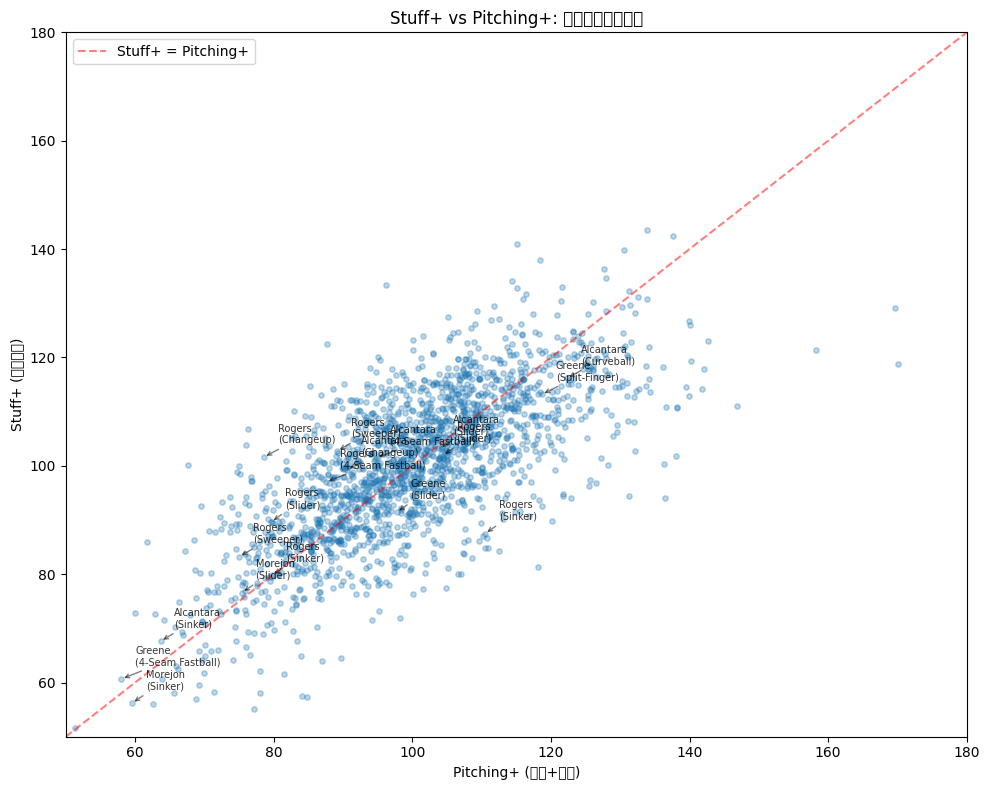

対角線より上 = 球質は良いが制球で損している投手
対角線より下 = 球質は平凡だが制球で稼いでいる投手


In [22]:
# ============================================================
# Stuff+ vs Pitching+ 散布図
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(comparison["pitching_plus"], comparison["stuff_plus"], alpha=0.3, s=15)

# 対角線（Stuff+ = Pitching+ の線）
lims = [50, 180]
ax.plot(lims, lims, 'r--', alpha=0.5, label="Stuff+ = Pitching+")

# 注目投手をアノテーション
highlight_names = ["Greene", "Alcantara", "Rogers", "Morejon"]
for name in highlight_names:
    rows = comparison[comparison["player_name"].str.contains(name, na=False)]
    for _, row in rows.iterrows():
        ax.annotate(
            f"{row['player_name'].split(',')[0]}\n({row['pitch_name']})",
            (row["pitching_plus"], row["stuff_plus"]),
            fontsize=7, alpha=0.8,
            arrowprops=dict(arrowstyle='->', alpha=0.5),
            textcoords="offset points", xytext=(10, 10)
        )

ax.set_xlabel("Pitching+ (球質+制球)")
ax.set_ylabel("Stuff+ (球質のみ)")
ax.set_title("Stuff+ vs Pitching+: 球質と制球の乖離")
ax.legend()
ax.set_xlim(50, 180)
ax.set_ylim(50, 180)
plt.tight_layout()
plt.show()

print("対角線より上 = 球質は良いが制球で損している投手")
print("対角線より下 = 球質は平凡だが制球で稼いでいる投手")

In [23]:
# ============================================================
# サマリー: 両モデルの比較
# ============================================================
print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"{'':20s} {'Pitching+':>12s} {'Stuff+':>12s}")
print("-" * 60)
print(f"{'Features':20s} {'13 (+plate_x/z)':>12s} {'11':>12s}")
print(f"{'Pitch-level R²':20s} {r2_score(y_test, model.predict(X_test)):>12.4f} {r2_score(y_s_test, y_s_pred):>12.4f}")
print(f"{'Agg Pearson r':20s} {corr_pearson_p:>12.4f} {corr_pearson_s:>12.4f}")
print(f"{'Agg Spearman r':20s} {corr_spearman_p:>12.4f} {corr_spearman_s:>12.4f}")
print("=" * 60)
print()
print("Pitching+ = 球質 + 制球の総合力。チーム評価・試合予測向き。")
print("Stuff+    = 純粋な球質。スカウティング・ドラフト評価向き。")
print("両方を持つことで、選手の強みの内訳（stuff vs command）を分析可能。")

MODEL COMPARISON SUMMARY
                        Pitching+       Stuff+
------------------------------------------------------------
Features             13 (+plate_x/z)           11
Pitch-level R²             0.0196       0.0004
Agg Pearson r              0.3875       0.2871
Agg Spearman r             0.3804       0.2752

Pitching+ = 球質 + 制球の総合力。チーム評価・試合予測向き。
Stuff+    = 純粋な球質。スカウティング・ドラフト評価向き。
両方を持つことで、選手の強みの内訳（stuff vs command）を分析可能。


## Pure Stuff+ Model (plate_x / plate_z を除外)

上記モデルは `plate_x`, `plate_z`（投球位置）を含んでおり、**Pitching+**（球質＋制球の総合指標）に相当する。

ここでは投球位置を除外し、**純粋な球質（Stuff）のみ**を評価するモデルを構築する。

- **Stuff+**: 球質のみ（速度、回転、変化量、リリースポイント、arm angle）
- **Pitching+**: 球質 ＋ 投球位置（上記 + plate_x/plate_z）

Hunter Greene の 4-Seam (99.5mph) が Pitching+ では低評価だったが、Stuff+ では適正に評価されるはず。